In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
import warnings
warnings.filterwarnings("ignore")

from src.preprocessing import impute_missing, convert_types
from src.features import add_features, add_neighborhood_features, add_target_encoding_features, FEATURES
from src.utils import run_cv, make_submission

In [2]:
train_df = pd.read_csv("../data/train.csv")
test_df  = pd.read_csv("../data/test.csv")

y = train_df["SalePrice"]
train_df = train_df.drop("SalePrice", axis=1)

df = pd.concat([train_df, test_df], axis=0).reset_index(drop=True)

In [3]:
# 前処理
df = impute_missing(df)
df = convert_types(df)

In [4]:
# 特徴量生成
df = add_features(df)

train = df.iloc[:len(y)].copy()
test  = df.iloc[len(y):].copy()

train = add_neighborhood_features(train, train)
test  = add_neighborhood_features(test, train)

# KFold Target Encoding
train["SalePrice"] = y.values
train, test = add_target_encoding_features(train, test, target_col="SalePrice")
train = train.drop("SalePrice", axis=1)

X_train = train[FEATURES]
y_train = np.log1p(y)
X_test  = test[FEATURES]

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)

X_train: (1460, 45)
X_test:  (1459, 45)


In [5]:
params = {
    "boosting_type" : "gbdt",
    "objective"     : "regression",
    "metric"        : "rmse",
    "learning_rate" : 0.1,
    "num_leaves"    : 16,
    "n_estimators"  : 100000,
    "random_state"  : 123,
    "importance_type": "gain",
}

metrics, imp = run_cv(X_train, y_train, params)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000550 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5133
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 45
[LightGBM] [Info] Start training from score 12.021806
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[62]	training's rmse: 0.0770986	valid_1's rmse: 0.117321
[fold 0] tr: 0.07710, va: 0.11732
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000410 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5116
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 45
[LightGBM] [Info] Start training from score 12.014343
Training until validation scores don't improve for 100 rounds
Ea

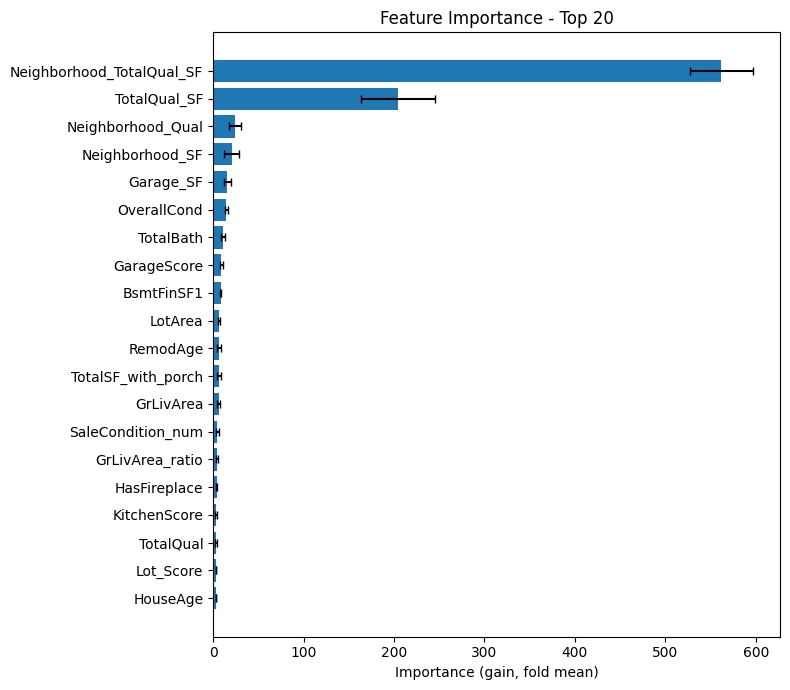

In [6]:
# 特徴量重要度 上位20件 棒グラフ
top20 = imp.head(20).sort_values("imp")

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top20.index, top20["imp"], xerr=top20["imp_std"], capsize=3)
ax.set_xlabel("Importance (gain, fold mean)")
ax.set_title("Feature Importance - Top 20")
plt.tight_layout()
plt.show()

In [ ]:
# 全データで再学習 → submission
model = lgb.LGBMRegressor(**params)
model.fit(X_train, y_train)

make_submission(
    model, X_test, test["Id"],
    filepath="../submissions/hp-submission_04_modeling.csv"
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011011 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5328
[LightGBM] [Info] Number of data points in the train set: 1460, number of used features: 45
[LightGBM] [Info] Start training from score 12.024057
